# GWHD 2021: Difficulty Score vs AP by Object Size

This notebook answers three questions:

1. Do very small and small objects have much lower AP than larger objects?
2. Are the highest difficulty scores concentrated on those low-AP size buckets?
3. If we improve those buckets, is the likely gain practically meaningful?

The notebook uses one baseline evaluation run plus the scoring file and training annotations so the analysis stays tied to the actual model behavior.

In [21]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from PIL import Image
except Exception:
    Image = None

# Core paths used in this notebook.
BASE_DIR = Path('/home/khanh/Projects/DifficultyAgri')
SCORE_PATH = BASE_DIR / 'results/055_multiseed_copy_paste_exp_gwhd_2021/seed_123/Step_3_Scoring_Dataset/score_results.json'
EVAL_PATH = BASE_DIR / 'results/055_multiseed_copy_paste_exp_gwhd_2021/seed_123/Step_2_Train_and_Evaluate_BASELINE_MODEL/evaluation_baseline_on_original_test.json'
TRAIN_CSV = BASE_DIR / 'datasets/global_wheat_head/raw_v2/gwhd_2021/competition_train.csv'

print('Score file exists:', SCORE_PATH.exists())
print('Evaluation file exists:', EVAL_PATH.exists())
print('Training CSV exists:', TRAIN_CSV.exists())

if not EVAL_PATH.exists():
    raise FileNotFoundError(f'Missing evaluation file: {EVAL_PATH}')
if not TRAIN_CSV.exists():
    raise FileNotFoundError(f'Missing training CSV: {TRAIN_CSV}')

with open(EVAL_PATH, 'r', encoding='utf-8') as f:
    eval_data = json.load(f)

train_df = pd.read_csv(TRAIN_CSV)

# The score file is large, so load it only if the file is present.
# The notebook still works if the score file is unavailable in this environment.
score_data = None
if SCORE_PATH.exists():
    try:
        with open(SCORE_PATH, 'r', encoding='utf-8') as f:
            score_data = json.load(f)
    except Exception as exc:
        print(f'Could not fully load score file: {exc}')
        score_data = None

print(f'Training rows: {len(train_df)}')
print(f'Evaluation metrics loaded: {list(eval_data.keys())}')
if score_data is not None:
    print(f"Score images loaded: {len(score_data.get('image_difficulties', []))}")

Score file exists: True
Evaluation file exists: True
Training CSV exists: True
Training rows: 3657
Evaluation metrics loaded: ['COCO_AP', 'COCO_AP50', 'COCO_AP75', 'AP_small', 'AP_medium', 'AP_large', 'AP_very_small', 'AP_small_20_32', 'AP_medium_gt_32']
Score images loaded: 3655


Baseline AP by size bucket
    size_bucket     ap  acceptable  gap_to_0_25
  AP_very_small 0.0070       False       0.2430
       AP_small 0.0647       False       0.1853
 AP_small_20_32 0.0738       False       0.1762
      AP_medium 0.2558        True       0.0000
AP_medium_gt_32 0.2642        True       0.0000
       AP_large 0.3827        True       0.0000


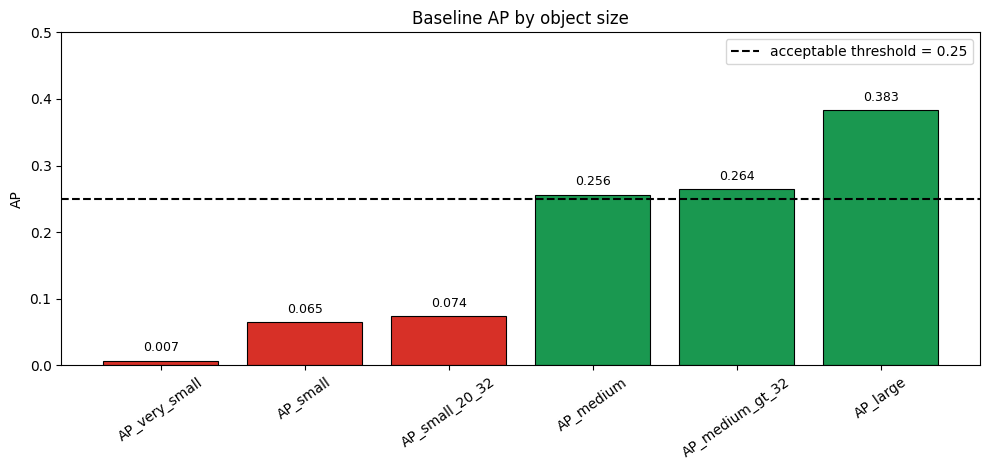

Low-AP buckets under the 0.25 acceptable range: ['AP_very_small', 'AP_small', 'AP_small_20_32']
Very small and small objects are well below the acceptable range.


In [22]:
ap_summary = pd.DataFrame(
    [
        {'size_bucket': 'AP_very_small', 'ap': eval_data.get('AP_very_small', np.nan)},
        {'size_bucket': 'AP_small', 'ap': eval_data.get('AP_small', np.nan)},
        {'size_bucket': 'AP_small_20_32', 'ap': eval_data.get('AP_small_20_32', np.nan)},
        {'size_bucket': 'AP_medium', 'ap': eval_data.get('AP_medium', np.nan)},
        {'size_bucket': 'AP_medium_gt_32', 'ap': eval_data.get('AP_medium_gt_32', np.nan)},
        {'size_bucket': 'AP_large', 'ap': eval_data.get('AP_large', np.nan)},
    ]
)

ap_summary['acceptable'] = ap_summary['ap'] >= 0.25
ap_summary['gap_to_0_25'] = 0.25 - ap_summary['ap']
ap_summary['gap_to_0_25'] = ap_summary['gap_to_0_25'].clip(lower=0)

print('Baseline AP by size bucket')
print(ap_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ['#d73027' if v < 0.25 else '#1a9850' for v in ap_summary['ap']]
ax.bar(ap_summary['size_bucket'], ap_summary['ap'], color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(0.25, color='black', linestyle='--', linewidth=1.5, label='acceptable threshold = 0.25')
ax.set_ylabel('AP')
ax.set_title('Baseline AP by object size')
ax.tick_params(axis='x', rotation=35)
ax.set_ylim(0, max(0.5, float(ap_summary['ap'].max()) * 1.15))
ax.legend()
for idx, value in enumerate(ap_summary['ap']):
    ax.text(idx, value + 0.01, f'{value:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

low_ap_buckets = ap_summary.loc[~ap_summary['acceptable'], 'size_bucket'].tolist()
print('Low-AP buckets under the 0.25 acceptable range:', low_ap_buckets)
if 'AP_very_small' in low_ap_buckets or 'AP_small' in low_ap_buckets:
    print('Very small and small objects are well below the acceptable range.')

In [23]:
if score_data is None:
    raise RuntimeError('The score file could not be loaded, so the score-vs-size analysis cannot run.')

image_difficulties = score_data.get('image_difficulties', [])
if not isinstance(image_difficulties, list) or len(image_difficulties) == 0:
    raise ValueError('score_results.json does not contain a usable image_difficulties list')

# Build a lookup from filename to image-level difficulty score.
score_rows = []
for item in image_difficulties:
    image_path = item.get('image_path', '')
    difficulty_score = item.get('difficulty_score', np.nan)
    if image_path and difficulty_score is not None:
        score_rows.append({
            'image_name': Path(image_path).name,
            'difficulty_score': float(difficulty_score),
        })

score_df = pd.DataFrame(score_rows).dropna()
print(f'Loaded image-level difficulty scores: {len(score_df)}')

# Parse image annotations from the training CSV.
# The boxes are stored in BoxesString as "x1 y1 x2 y2;..." in pixel coordinates.
def parse_boxes(boxes_string: str):
    if not isinstance(boxes_string, str) or not boxes_string.strip():
        return []
    boxes = []
    for raw_box in boxes_string.split(';'):
        raw_box = raw_box.strip()
        if not raw_box:
            continue
        parts = raw_box.split()
        if len(parts) < 4:
            continue
        x1, y1, x2, y2 = map(float, parts[:4])
        width = max(0.0, x2 - x1)
        height = max(0.0, y2 - y1)
        area_px = width * height
        equiv_side = math.sqrt(area_px) if area_px > 0 else 0.0
        boxes.append({
            'area_px': area_px,
            'equiv_side': equiv_side,
        })
    return boxes

# Size buckets are defined by equivalent side length in pixels.
# This keeps the buckets easy to interpret and matches the general idea behind very small / small / medium / large AP.
def size_bucket_from_side(side_px: float) -> str:
    if side_px < 20:
        return 'very_small'
    if side_px < 32:
        return 'small'
    if side_px < 96:
        return 'medium'
    return 'large'

object_rows = []
for row in train_df.itertuples(index=False):
    image_name = getattr(row, 'image_name')
    boxes = parse_boxes(getattr(row, 'BoxesString'))
    for box in boxes:
        bucket = size_bucket_from_side(box['equiv_side'])
        object_rows.append({
            'image_name': image_name,
            'size_bucket': bucket,
            'area_px': box['area_px'],
            'equiv_side': box['equiv_side'],
        })

object_df = pd.DataFrame(object_rows)
if object_df.empty:
    raise RuntimeError('No objects were parsed from the training CSV')

bucket_order = ['very_small', 'small', 'medium', 'large']
object_df['size_bucket'] = pd.Categorical(object_df['size_bucket'], categories=bucket_order, ordered=True)

print(f'Parsed objects: {len(object_df)}')
print(object_df['size_bucket'].value_counts().reindex(bucket_order))

# Aggregate to the image level so we can relate score to object-size composition.
image_bucket_counts = (
    object_df.groupby(['image_name', 'size_bucket'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=bucket_order, fill_value=0)
)
image_bucket_counts['n_objects'] = image_bucket_counts.sum(axis=1)
for bucket in bucket_order:
    image_bucket_counts[f'prop_{bucket}'] = image_bucket_counts[bucket] / image_bucket_counts['n_objects']

image_bucket_counts = image_bucket_counts.reset_index()
image_analysis = score_df.merge(image_bucket_counts, on='image_name', how='inner')

print(f'Images with both score and size composition: {len(image_analysis)}')
print(image_analysis[['difficulty_score', 'n_objects', 'prop_very_small', 'prop_small', 'prop_medium', 'prop_large']].describe().round(4))

Loaded image-level difficulty scores: 3655
Parsed objects: 163690
size_bucket
very_small       169
small           1940
medium        134314
large          27267
Name: count, dtype: int64
Images with both score and size composition: 3605
       difficulty_score  n_objects  prop_very_small  prop_small  prop_medium  \
count         3605.0000  3605.0000        3605.0000   3605.0000    3605.0000   
mean             0.3297    45.4064           0.0007      0.0087       0.7865   
std              0.1073    20.5218           0.0054      0.0287       0.2064   
min              0.1154     1.0000           0.0000      0.0000       0.0000   
25%              0.2578    30.0000           0.0000      0.0000       0.6857   
50%              0.3127    45.0000           0.0000      0.0000       0.8571   
75%              0.3816    60.0000           0.0000      0.0000       0.9412   
max              1.6365   129.0000           0.1429      0.4848       1.0000   

       prop_large  
count   3605.0000  
m

In [24]:
def bootstrap_mean_ci(values, n_boot=2000, ci=95, seed=42):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    boot_means = samples.mean(axis=1)
    alpha = (100 - ci) / 2
    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)
    return float(values.mean()), float(lower), float(upper)

# Correlate score with object-size composition.
correlation_rows = []
for bucket in bucket_order:
    prop_col = f'prop_{bucket}'
    pearson = image_analysis['difficulty_score'].corr(image_analysis[prop_col], method='pearson')
    spearman = image_analysis['difficulty_score'].corr(image_analysis[prop_col], method='spearman')
    correlation_rows.append({
        'size_bucket': bucket,
        'pearson_score_vs_prop': pearson,
        'spearman_score_vs_prop': spearman,
        'mean_image_score': bootstrap_mean_ci(image_analysis.loc[image_analysis[prop_col] > 0, 'difficulty_score'])[0],
    })

correlation_df = pd.DataFrame(correlation_rows)
print('Correlation between image difficulty score and size composition')
print(correlation_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Score summaries by dominant bucket.
image_analysis['dominant_bucket'] = image_analysis[[f'prop_{b}' for b in bucket_order]].idxmax(axis=1).str.replace('prop_', '', regex=False)
dominant_summary = []
for bucket in bucket_order:
    subset = image_analysis[image_analysis['dominant_bucket'] == bucket]
    mean_score, ci_low, ci_high = bootstrap_mean_ci(subset['difficulty_score'])
    dominant_summary.append({
        'dominant_bucket': bucket,
        'n_images': len(subset),
        'mean_score': mean_score,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'median_score': float(subset['difficulty_score'].median()) if len(subset) else np.nan,
        'mean_prop_in_bucket': float(subset[f'prop_{bucket}'].mean()) if len(subset) else np.nan,
    })

dominant_summary_df = pd.DataFrame(dominant_summary)
print('\nDifficulty score by dominant size bucket')
print(dominant_summary_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# High-difficulty images and low-AP-prone composition.
high_difficulty_threshold = image_analysis['difficulty_score'].quantile(0.75)
high_difficulty_images = image_analysis[image_analysis['difficulty_score'] >= high_difficulty_threshold].copy()
high_difficulty_images['low_ap_prone_majority'] = (
    (high_difficulty_images['prop_very_small'] + high_difficulty_images['prop_small']) >= 0.5
)
low_ap_share_high_diff = high_difficulty_images['low_ap_prone_majority'].mean()
low_ap_share_all = ((image_analysis['prop_very_small'] + image_analysis['prop_small']) >= 0.5).mean()

print('\nHigh-difficulty concentration check')
print(f'High-difficulty threshold: {high_difficulty_threshold:.4f}')
print(f'High-difficulty images dominated by very_small/small objects: {100 * low_ap_share_high_diff:.1f}%')
print(f'All images dominated by very_small/small objects: {100 * low_ap_share_all:.1f}%')

if low_ap_share_high_diff > low_ap_share_all:
    print('High-difficulty images are enriched for low-AP-prone small-object images.')
else:
    print('High-difficulty images are not strongly concentrated in low-AP-prone small-object images.')

Correlation between image difficulty score and size composition
size_bucket  pearson_score_vs_prop  spearman_score_vs_prop  mean_image_score
 very_small                 0.1152                  0.0620            0.3639
      small                 0.1759                  0.1194            0.3549
     medium                 0.0153                 -0.0168            0.3295
      large                -0.0422                 -0.0263            0.3238

Difficulty score by dominant size bucket
dominant_bucket  n_images  mean_score  ci_low  ci_high  median_score  mean_prop_in_bucket
     very_small         0         NaN     NaN      NaN           NaN                  NaN
          small         1      0.6807  0.6807   0.6807        0.6807               0.4286
         medium      3205      0.3303  0.3265   0.3340        0.3134               0.8428
          large       399      0.3238  0.3138   0.3338        0.3071               0.6598

High-difficulty concentration check
High-difficulty thresh

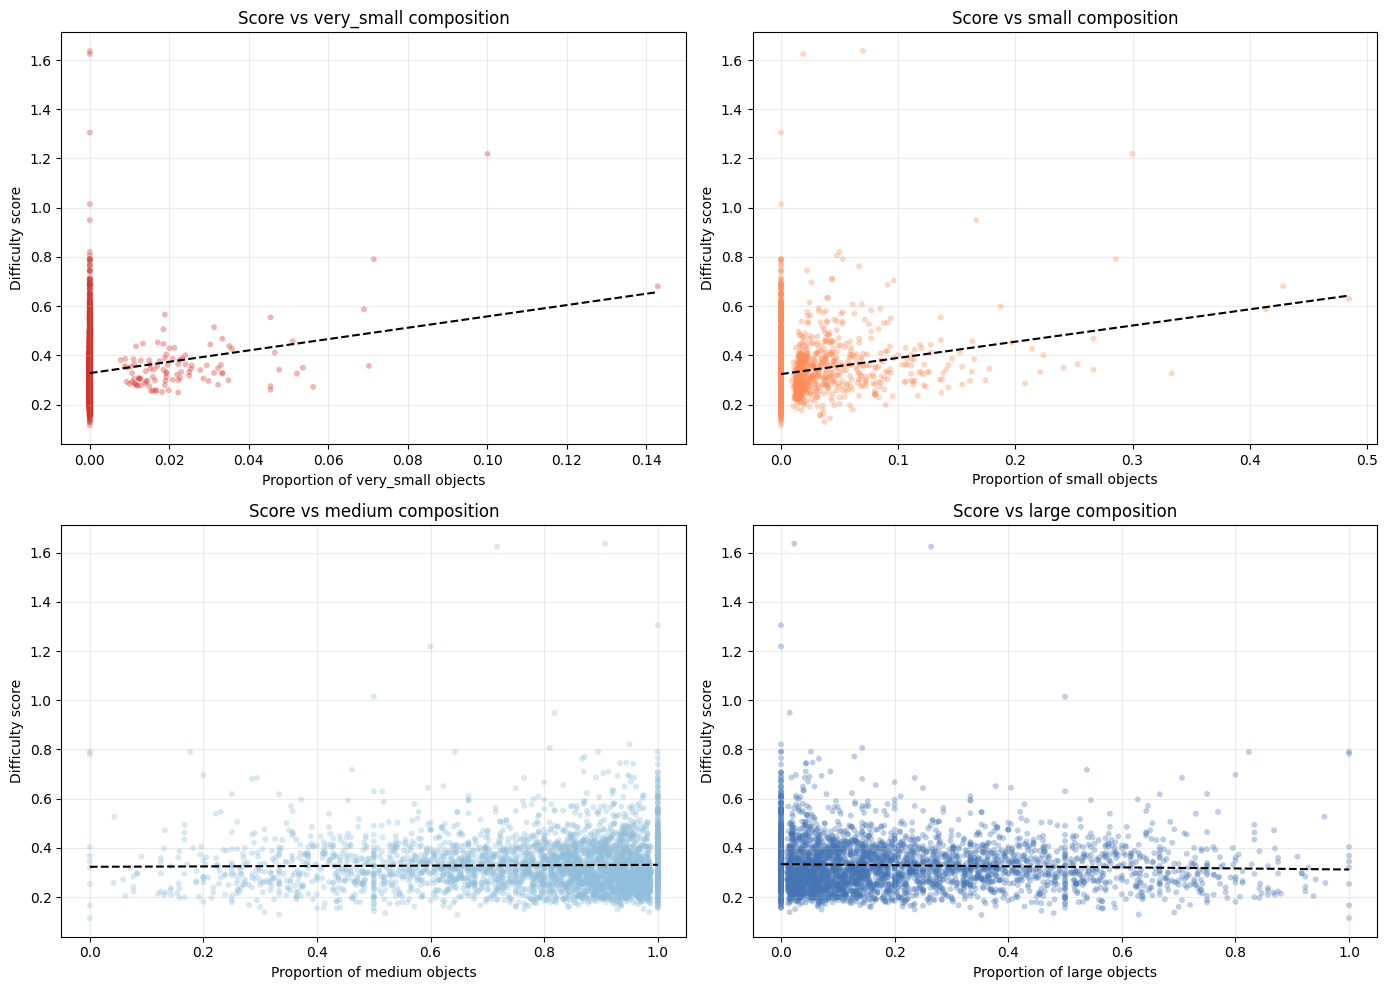

/tmp/ipykernel_66174/882187455.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=bucket_order, showmeans=True)


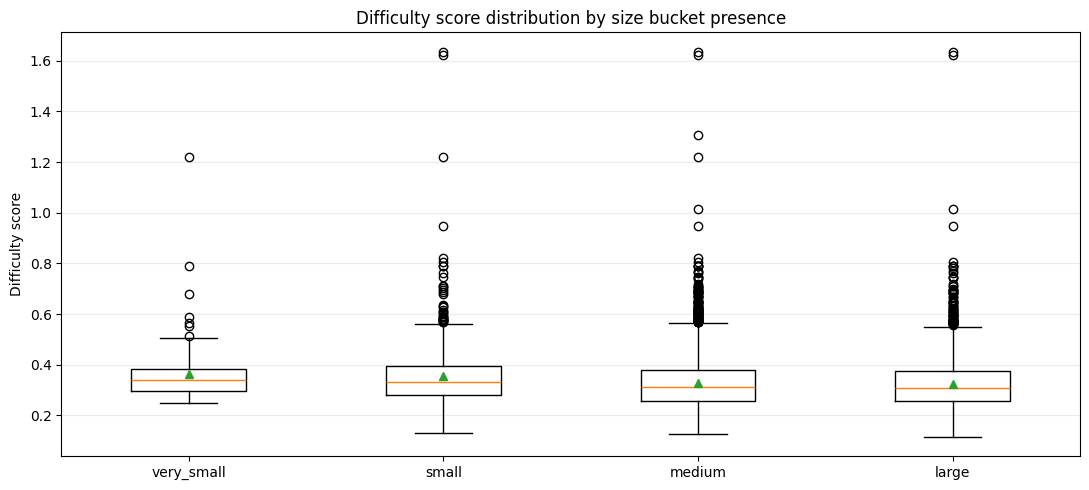

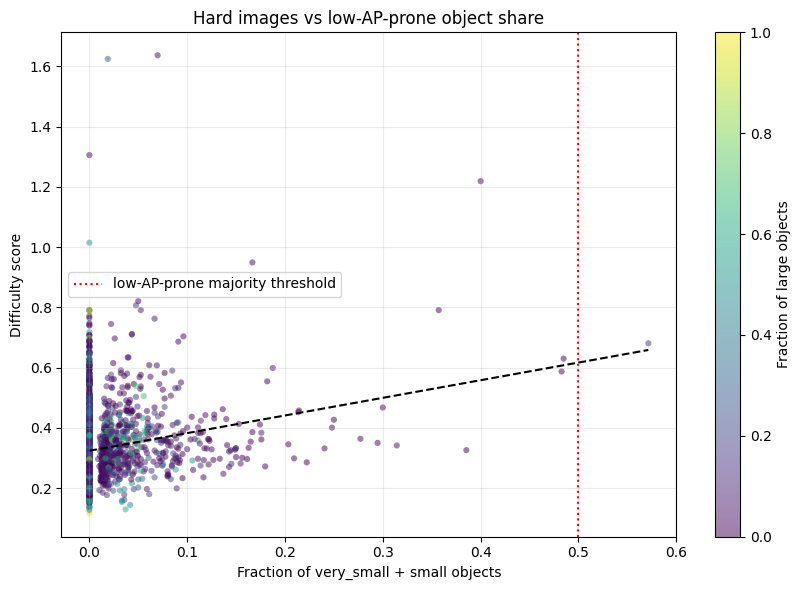

In [25]:
def add_trendline(ax, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return
    x = x[mask]
    y = y[mask]
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color='black', linestyle='--', linewidth=1.5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palette = {
    'very_small': '#d73027',
    'small': '#fc8d59',
    'medium': '#91bfdb',
    'large': '#4575b4',
}

for idx, bucket in enumerate(bucket_order):
    ax = axes[idx]
    prop_col = f'prop_{bucket}'
    ax.scatter(
        image_analysis[prop_col],
        image_analysis['difficulty_score'],
        s=18,
        alpha=0.35,
        color=palette[bucket],
        edgecolors='none',
    )
    add_trendline(ax, image_analysis[prop_col], image_analysis['difficulty_score'])
    ax.set_xlabel(f'Proportion of {bucket} objects')
    ax.set_ylabel('Difficulty score')
    ax.set_title(f'Score vs {bucket} composition')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
box_data = [image_analysis.loc[image_analysis[f'prop_{b}'] > 0, 'difficulty_score'] for b in bucket_order]
ax.boxplot(box_data, labels=bucket_order, showmeans=True)
ax.set_ylabel('Difficulty score')
ax.set_title('Difficulty score distribution by size bucket presence')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# A compact view of where the hardest images sit.
fig, ax = plt.subplots(figsize=(8.5, 6))
scatter = ax.scatter(
    image_analysis['prop_very_small'] + image_analysis['prop_small'],
    image_analysis['difficulty_score'],
    c=image_analysis['prop_large'],
    cmap='viridis',
    s=20,
    alpha=0.5,
    edgecolors='none',
)
add_trendline(ax, image_analysis['prop_very_small'] + image_analysis['prop_small'], image_analysis['difficulty_score'])
ax.axvline(0.5, color='red', linestyle=':', linewidth=1.5, label='low-AP-prone majority threshold')
ax.set_xlabel('Fraction of very_small + small objects')
ax.set_ylabel('Difficulty score')
ax.set_title('Hard images vs low-AP-prone object share')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Fraction of large objects')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [26]:
object_bucket_share = object_df['size_bucket'].value_counts(normalize=True).reindex(bucket_order, fill_value=0)
object_bucket_counts = object_df['size_bucket'].value_counts().reindex(bucket_order, fill_value=0)

print('Object share by size bucket')
print((100 * object_bucket_share).round(2).astype(str) + '%')

# Treat very_small and small as the low-AP buckets.
low_buckets = ['very_small', 'small']
low_bucket_share = float(object_bucket_share.loc[low_buckets].sum())
low_bucket_ap = float(np.average(
    [ap_summary.loc[ap_summary['size_bucket'] == 'AP_very_small', 'ap'].iloc[0],
     ap_summary.loc[ap_summary['size_bucket'] == 'AP_small', 'ap'].iloc[0]],
    weights=[object_bucket_share['very_small'], object_bucket_share['small']]
))
medium_ap = float(ap_summary.loc[ap_summary['size_bucket'] == 'AP_medium', 'ap'].iloc[0])
large_ap = float(ap_summary.loc[ap_summary['size_bucket'] == 'AP_large', 'ap'].iloc[0])

rough_uplift_to_medium = low_bucket_share * max(0.0, medium_ap - low_bucket_ap)
rough_uplift_to_large = low_bucket_share * max(0.0, large_ap - low_bucket_ap)

print('\nPractical impact estimate')
print(f'Fraction of all objects that are very_small or small: {100 * low_bucket_share:.1f}%')
print(f'Weighted low-bucket AP today: {low_bucket_ap:.4f}')
print(f'Medium-bucket AP reference: {medium_ap:.4f}')
print(f'Large-bucket AP reference: {large_ap:.4f}')
print(f'Rough overall AP gain if low buckets rose to medium AP: {rough_uplift_to_medium:.4f}')
print(f'Rough overall AP gain if low buckets rose to large AP: {rough_uplift_to_large:.4f}')

if low_bucket_share < 0.35:
    print('Low-AP objects are a minority of the dataset, so even a strong gain there may have limited impact on overall AP.')
else:
    print('Low-AP objects are common enough that improving them could have a noticeable effect on overall AP.')

if rough_uplift_to_medium < 0.03:
    print('This suggests that pushing harder on the low-AP buckets may give only a modest total AP improvement.')
else:
    print('This suggests that improving the low-AP buckets could be practically worthwhile.')

Object share by size bucket
size_bucket
very_small      0.1%
small          1.19%
medium        82.05%
large         16.66%
Name: proportion, dtype: str

Practical impact estimate
Fraction of all objects that are very_small or small: 1.3%
Weighted low-bucket AP today: 0.0601
Medium-bucket AP reference: 0.2558
Large-bucket AP reference: 0.3827
Rough overall AP gain if low buckets rose to medium AP: 0.0025
Rough overall AP gain if low buckets rose to large AP: 0.0042
Low-AP objects are a minority of the dataset, so even a strong gain there may have limited impact on overall AP.
This suggests that pushing harder on the low-AP buckets may give only a modest total AP improvement.


## What to look for

If the notebook shows that `AP_very_small` and `AP_small` are far below the 0.25 acceptable range, while the difficulty scores are concentrated on images dominated by those buckets, then the model is failing mostly on tiny objects.

If the estimated AP gain from improving those buckets is small, that means the score is correctly identifying hard cases, but pushing harder on them may not translate into a large overall AP improvement.

That is the practical tradeoff this notebook is meant to expose.

In [27]:
top20_threshold = image_analysis['difficulty_score'].quantile(0.80)
top20_images = image_analysis[image_analysis['difficulty_score'] >= top20_threshold].copy()

top20_share_very_small = float((top20_images['prop_very_small'] > 0).mean())
top20_share_small = float((top20_images['prop_small'] > 0).mean())
top20_share_any_low = float(((top20_images['prop_very_small'] + top20_images['prop_small']) > 0).mean())
top20_mean_low_prop = float((top20_images['prop_very_small'] + top20_images['prop_small']).mean())

print(f'Top 20% score threshold: {top20_threshold:.4f}')
print(f'N images in top 20%: {len(top20_images)}')
print(f'Images with any very_small objects: {100 * top20_share_very_small:.1f}%')
print(f'Images with any small objects: {100 * top20_share_small:.1f}%')
print(f'Images with any very_small or small objects: {100 * top20_share_any_low:.1f}%')
print(f'Average fraction of very_small + small objects in top 20% images: {100 * top20_mean_low_prop:.2f}%')

# Compare against the full dataset for context.
full_share_very_small = float((image_analysis['prop_very_small'] > 0).mean())
full_share_small = float((image_analysis['prop_small'] > 0).mean())
full_share_any_low = float(((image_analysis['prop_very_small'] + image_analysis['prop_small']) > 0).mean())
full_mean_low_prop = float((image_analysis['prop_very_small'] + image_analysis['prop_small']).mean())

print('\nDataset baseline')
print(f'Images with any very_small objects: {100 * full_share_very_small:.1f}%')
print(f'Images with any small objects: {100 * full_share_small:.1f}%')
print(f'Images with any very_small or small objects: {100 * full_share_any_low:.1f}%')
print(f'Average fraction of very_small + small objects in all images: {100 * full_mean_low_prop:.2f}%')

if top20_mean_low_prop > full_mean_low_prop:
    print('\nThe top-score group is enriched for very_small/small objects compared with the dataset as a whole.')
else:
    print('\nThe top-score group is not enriched for very_small/small objects compared with the dataset as a whole.')

Top 20% score threshold: 0.3996
N images in top 20%: 721
Images with any very_small objects: 3.1%
Images with any small objects: 22.1%
Images with any very_small or small objects: 22.5%
Average fraction of very_small + small objects in top 20% images: 1.57%

Dataset baseline
Images with any very_small objects: 2.9%
Images with any small objects: 18.6%
Images with any very_small or small objects: 18.9%
Average fraction of very_small + small objects in all images: 0.95%

The top-score group is enriched for very_small/small objects compared with the dataset as a whole.


## Strategy To Prove Or Reject The Hypothesis

Hypothesis to test:

- **H1**: high-score images concentrate on object-size buckets where baseline AP is near zero.
- **H0**: high-score images are not especially concentrated on those low-AP buckets.

Operational definitions used below:

1. **Near-zero AP bucket**: AP <= `near_zero_ap_threshold` (default 0.10).
2. **High-score images**: top `high_score_quantile` by difficulty score (default top 20%).
3. **Concentration signal**:
   - Enrichment in low-AP object fraction for high-score images vs the rest.
   - Share of all low-AP objects captured by high-score images vs random expectation.
4. **Statistical proof**:
   - Permutation test for mean low-AP fraction difference.
   - Bootstrap confidence interval for capture-share lift.

Decision rule:

- Conclude concentration is **supported** if p-value < 0.05 and lift over random is clearly > 1.
- Otherwise conclude concentration is **not strongly supported**.

AP by bucket used for hypothesis test:
  very_small: 0.0070
  small     : 0.0647
  medium    : 0.2558
  large     : 0.3827
Near-zero AP buckets (<= 0.10): ['very_small', 'small']

=== Hypothesis Test Results ===
High-score threshold quantile: 0.80 (score >= 0.3996)
N high-score images: 721 / 3605
Mean low-AP-bucket fraction (high-score): 0.0157
Mean low-AP-bucket fraction (rest):       0.0079
Difference (high - rest):                  0.0078
Mean-fraction lift:                        1.979x
Permutation p-value:                       0.00000

Concentration by low-AP object counts
Capture share in high-score images:        0.2684
Random expectation for top group:          0.2000
Capture lift vs random:                    1.342x
95% bootstrap CI for capture share:        [0.2111, 0.3218]

Verdict:
SUPPORTED: high-score images do concentrate on near-zero-AP buckets.


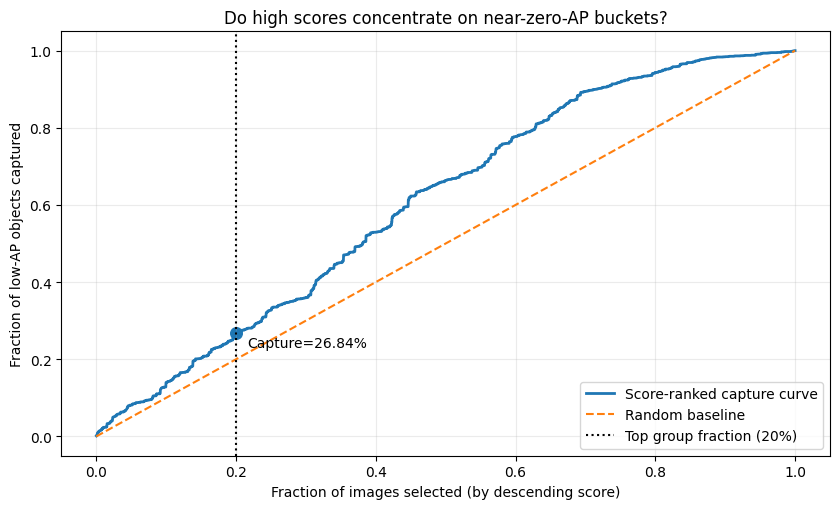

In [28]:
near_zero_ap_threshold = 0.10
high_score_quantile = 0.80
n_perm = 5000
n_boot = 3000
rng = np.random.default_rng(123)

# Map notebook size buckets to baseline AP metrics.
bucket_to_ap_metric = {
    'very_small': 'AP_very_small',
    'small': 'AP_small',
    'medium': 'AP_medium',
    'large': 'AP_large',
}

bucket_ap = {
    b: float(eval_data.get(metric, np.nan))
    for b, metric in bucket_to_ap_metric.items()
}

near_zero_buckets = [b for b, apv in bucket_ap.items() if np.isfinite(apv) and apv <= near_zero_ap_threshold]
if len(near_zero_buckets) == 0:
    raise RuntimeError(
        f'No bucket has AP <= {near_zero_ap_threshold:.2f}. '
        'Adjust near_zero_ap_threshold if needed.'
    )

print('AP by bucket used for hypothesis test:')
for b in bucket_order:
    print(f'  {b:<10s}: {bucket_ap[b]:.4f}')
print(f'Near-zero AP buckets (<= {near_zero_ap_threshold:.2f}): {near_zero_buckets}')

# Build low-AP share per image.
low_ap_prop_col = 'prop_low_ap_buckets'
image_test = image_analysis.copy()
image_test[low_ap_prop_col] = 0.0
for b in near_zero_buckets:
    image_test[low_ap_prop_col] += image_test[f'prop_{b}']

# High-score split.
score_cut = image_test['difficulty_score'].quantile(high_score_quantile)
is_high = image_test['difficulty_score'] >= score_cut
high_group = image_test[is_high]
rest_group = image_test[~is_high]

mean_high = float(high_group[low_ap_prop_col].mean())
mean_rest = float(rest_group[low_ap_prop_col].mean())
delta_mean = mean_high - mean_rest
lift_mean = mean_high / mean_rest if mean_rest > 0 else np.nan

# Permutation test for difference in means.
all_vals = image_test[low_ap_prop_col].to_numpy(dtype=float)
labels = is_high.to_numpy()
n_high = labels.sum()
obs = delta_mean
perm_stats = np.empty(n_perm, dtype=float)
for i in range(n_perm):
    perm = rng.permutation(all_vals)
    perm_stats[i] = perm[:n_high].mean() - perm[n_high:].mean()

p_value = float((np.abs(perm_stats) >= abs(obs)).mean())

# Concentration by object counts: what share of all low-AP objects are in high-score images?
low_ap_object_count_col = 'n_low_ap_objects'
image_test[low_ap_object_count_col] = 0
for b in near_zero_buckets:
    image_test[low_ap_object_count_col] += image_test[b].astype(int)

total_low_ap_objects = int(image_test[low_ap_object_count_col].sum())
high_low_ap_objects = int(image_test.loc[is_high, low_ap_object_count_col].sum())

capture_share = high_low_ap_objects / total_low_ap_objects if total_low_ap_objects > 0 else np.nan
expected_share = 1.0 - high_score_quantile
capture_lift = capture_share / expected_share if expected_share > 0 else np.nan

# Bootstrap CI for capture share.
if total_low_ap_objects > 0:
    idx = np.arange(len(image_test))
    boot_capture = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sample_idx = rng.choice(idx, size=len(idx), replace=True)
        boot_df = image_test.iloc[sample_idx]
        boot_is_high = boot_df['difficulty_score'] >= boot_df['difficulty_score'].quantile(high_score_quantile)
        denom = boot_df[low_ap_object_count_col].sum()
        if denom == 0:
            boot_capture[i] = np.nan
        else:
            boot_capture[i] = boot_df.loc[boot_is_high, low_ap_object_count_col].sum() / denom
    boot_capture = boot_capture[np.isfinite(boot_capture)]
    ci_low, ci_high = np.percentile(boot_capture, [2.5, 97.5]) if len(boot_capture) else (np.nan, np.nan)
else:
    ci_low, ci_high = np.nan, np.nan

print('\n=== Hypothesis Test Results ===')
print(f'High-score threshold quantile: {high_score_quantile:.2f} (score >= {score_cut:.4f})')
print(f'N high-score images: {len(high_group)} / {len(image_test)}')
print(f'Mean low-AP-bucket fraction (high-score): {mean_high:.4f}')
print(f'Mean low-AP-bucket fraction (rest):       {mean_rest:.4f}')
print(f'Difference (high - rest):                  {delta_mean:.4f}')
print(f'Mean-fraction lift:                        {lift_mean:.3f}x')
print(f'Permutation p-value:                       {p_value:.5f}')

print('\nConcentration by low-AP object counts')
print(f'Capture share in high-score images:        {capture_share:.4f}')
print(f'Random expectation for top group:          {expected_share:.4f}')
print(f'Capture lift vs random:                    {capture_lift:.3f}x')
print(f'95% bootstrap CI for capture share:        [{ci_low:.4f}, {ci_high:.4f}]')

supported = (p_value < 0.05) and (capture_lift > 1.05)
print('\nVerdict:')
if supported:
    print('SUPPORTED: high-score images do concentrate on near-zero-AP buckets.')
else:
    print('NOT STRONGLY SUPPORTED: concentration is weak or not statistically clear.')

# Visual proof plot: cumulative capture curve vs random.
ranked = image_test.sort_values('difficulty_score', ascending=False).reset_index(drop=True)
ranked['cum_low_ap_objects'] = ranked[low_ap_object_count_col].cumsum()
if total_low_ap_objects > 0:
    ranked['capture_curve'] = ranked['cum_low_ap_objects'] / total_low_ap_objects
else:
    ranked['capture_curve'] = 0.0
ranked['x_frac_images'] = (np.arange(len(ranked)) + 1) / len(ranked)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(ranked['x_frac_images'], ranked['capture_curve'], label='Score-ranked capture curve', linewidth=2.0)
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5, label='Random baseline')
ax.axvline(expected_share, linestyle=':', linewidth=1.5, color='black', label=f'Top group fraction ({expected_share:.0%})')
if np.isfinite(capture_share):
    ax.scatter([expected_share], [capture_share], s=70)
    ax.annotate(f'Capture={capture_share:.2%}', (expected_share, capture_share), xytext=(8, -10), textcoords='offset points')
ax.set_xlabel('Fraction of images selected (by descending score)')
ax.set_ylabel('Fraction of low-AP objects captured')
ax.set_title('Do high scores concentrate on near-zero-AP buckets?')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()